# HIPE-2026 Error Analysis — In-Domain Test (n=401)

**Goal:** Understand *where* our models fail on the 401-pair in-domain test set.
The headline macro-recall metric (mean of `at` macro-recall and `isAt` macro-recall)
hides which classes, languages, and entity-coverage regimes drive the errors.

**Task:** Each (person, place) pair is labelled with
- `at` ∈ {FALSE, PROBABLE, TRUE} — strength of the place relationship
- `isAt` ∈ {FALSE, TRUE} — binary presence

**Models analysed:** `majority`, `embedding_svm`, `xlmr`, `llm_lookup`  
**Deep-dive model:** `xlmr` (best learned model on the 401-pair set, global=0.58)

Best run per model (n_dev==401, ranked by global score):
| model | run_id | global |
|---|---|---|
| majority | 2026-06-22_175657_majority_38726ddc | 0.4167 |
| embedding_svm | 2026-06-22_175716_embedding_svm_afbde9a9 | 0.5186 |
| xlmr | 2026-06-22_153045_xlmr_07e7698b | 0.5800 |
| llm_lookup | 2026-06-22_175710_llm_lookup_eb9720af | 0.6354 |

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
import matplotlib
matplotlib.use("Agg")

import sys
import io
import base64
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from sklearn.metrics import recall_score, confusion_matrix
from IPython.display import Image, display

sys.path.insert(0, "/Users/mayadeneva/Documents/uni/ozt/hipe")
from hipe.data.pairs import load_pairs, pair_key

RUNS_DIR = "/Users/mayadeneva/Documents/uni/ozt/hipe/runs"

MODEL_RUNS = {
    "majority":      "2026-06-22_175657_majority_38726ddc",
    "embedding_svm": "2026-06-22_175716_embedding_svm_afbde9a9",
    "xlmr":          "2026-06-22_153045_xlmr_07e7698b",
    "llm_lookup":    "2026-06-22_175710_llm_lookup_eb9720af",
}
XLMR_RUN = MODEL_RUNS["xlmr"]

AT_LABELS  = ["FALSE", "PROBABLE", "TRUE"]
ISAT_LABELS = ["FALSE", "TRUE"]

def show_fig(fig, save_path=None):
    """Save figure to bytes and display inline, optionally also save to file."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
    buf.seek(0)
    if save_path:
        with open(save_path, "wb") as f:
            f.write(buf.getvalue())
        buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

print("Environment ready.")

Environment ready.


## 1. Load Gold + Predictions

In [2]:
gold_path = f"{RUNS_DIR}/{XLMR_RUN}/predictions/dev_gold.jsonl"
gold_pairs = load_pairs(gold_path)
gold_index = {(p.doc_id, pair_key(p)): p for p in gold_pairs}
print(f"Gold pairs loaded: {len(gold_pairs)}")
assert len(gold_pairs) == 401, f"Expected 401, got {len(gold_pairs)}"

# Verify all run dirs have same 401 gold pairs
for model, run_id in MODEL_RUNS.items():
    gp = load_pairs(f"{RUNS_DIR}/{run_id}/predictions/dev_gold.jsonl")
    assert len(gp) == 401, f"{model}: expected 401, got {len(gp)}"
print("All runs have 401 gold pairs — verified.")

# Load predictions for each model
pred_data = {}
for model, run_id in MODEL_RUNS.items():
    preds = load_pairs(f"{RUNS_DIR}/{run_id}/predictions/dev.jsonl")
    pred_index = {(p.doc_id, pair_key(p)): p for p in preds}
    pred_data[model] = pred_index
    print(f"  {model}: {len(preds)} predictions")

# Build aligned arrays
gold_keys = [(p.doc_id, pair_key(p)) for p in gold_pairs]

gold_at   = [gold_index[k].gold_at   for k in gold_keys]
gold_isat = [gold_index[k].gold_isat for k in gold_keys]

pred_at   = {}
pred_isat = {}
for model, pidx in pred_data.items():
    pred_at[model]   = [pidx[k].gold_at   for k in gold_keys]
    pred_isat[model] = [pidx[k].gold_isat for k in gold_keys]

print("\nAlignment complete.")

Gold pairs loaded: 401

All runs have 401 gold pairs — verified.
  majority: 401 predictions


  embedding_svm: 401 predictions
  xlmr: 401 predictions


  llm_lookup: 401 predictions

Alignment complete.


## 2. Label Distribution

How imbalanced is the test set? The PROBABLE class is rare, and isAt skews heavily toward FALSE.

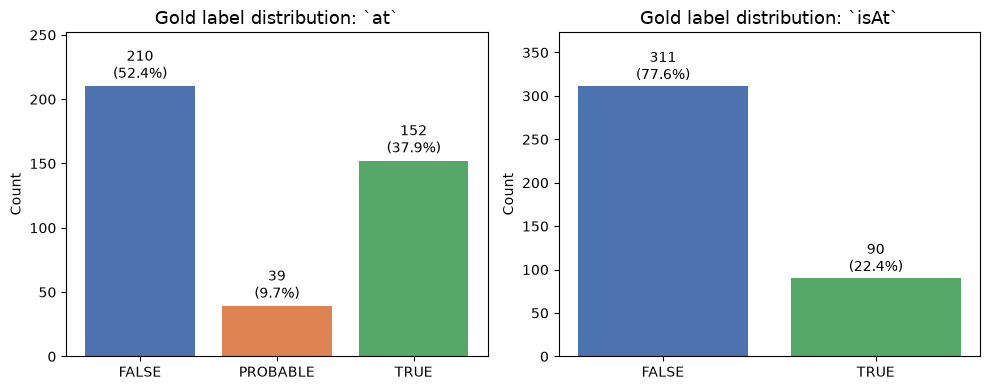


--- `at` label counts ---
  FALSE     :  210  ( 52.4%)
  PROBABLE  :   39  (  9.7%)
  TRUE      :  152  ( 37.9%)

--- `isAt` label counts ---
  FALSE     :  311  ( 77.6%)
  TRUE      :   90  ( 22.4%)

Key imbalance: PROBABLE is the smallest at-class; isAt is ~78% FALSE.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# at distribution
at_counts = Counter(gold_at)
at_vals = [at_counts.get(l, 0) for l in AT_LABELS]
ax = axes[0]
bars = ax.bar(AT_LABELS, at_vals, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Gold label distribution: `at`", fontsize=13)
ax.set_ylabel("Count")
for bar, v in zip(bars, at_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{v}\n({100*v/len(gold_at):.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, max(at_vals) * 1.2)

# isAt distribution
isat_counts = Counter(gold_isat)
isat_vals = [isat_counts.get(l, 0) for l in ISAT_LABELS]
ax2 = axes[1]
bars2 = ax2.bar(ISAT_LABELS, isat_vals, color=["#4C72B0", "#55A868"])
ax2.set_title("Gold label distribution: `isAt`", fontsize=13)
ax2.set_ylabel("Count")
for bar, v in zip(bars2, isat_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"{v}\n({100*v/len(gold_isat):.1f}%)", ha="center", va="bottom", fontsize=10)
ax2.set_ylim(0, max(isat_vals) * 1.2)

plt.tight_layout()
show_fig(fig, "/Users/mayadeneva/Documents/uni/ozt/hipe/notebooks/03_label_dist.png")

print("\n--- `at` label counts ---")
for l in AT_LABELS:
    n = at_counts.get(l, 0)
    print(f"  {l:10s}: {n:4d}  ({100*n/len(gold_at):5.1f}%)")

print("\n--- `isAt` label counts ---")
for l in ISAT_LABELS:
    n = isat_counts.get(l, 0)
    print(f"  {l:10s}: {n:4d}  ({100*n/len(gold_isat):5.1f}%)")

print("\nKey imbalance: PROBABLE is the smallest at-class; isAt is ~78% FALSE.")

## 3. Confusion Matrices

For each model: `at` (3×3) and `isAt` (2×2), raw counts and row-normalised (recall per cell).

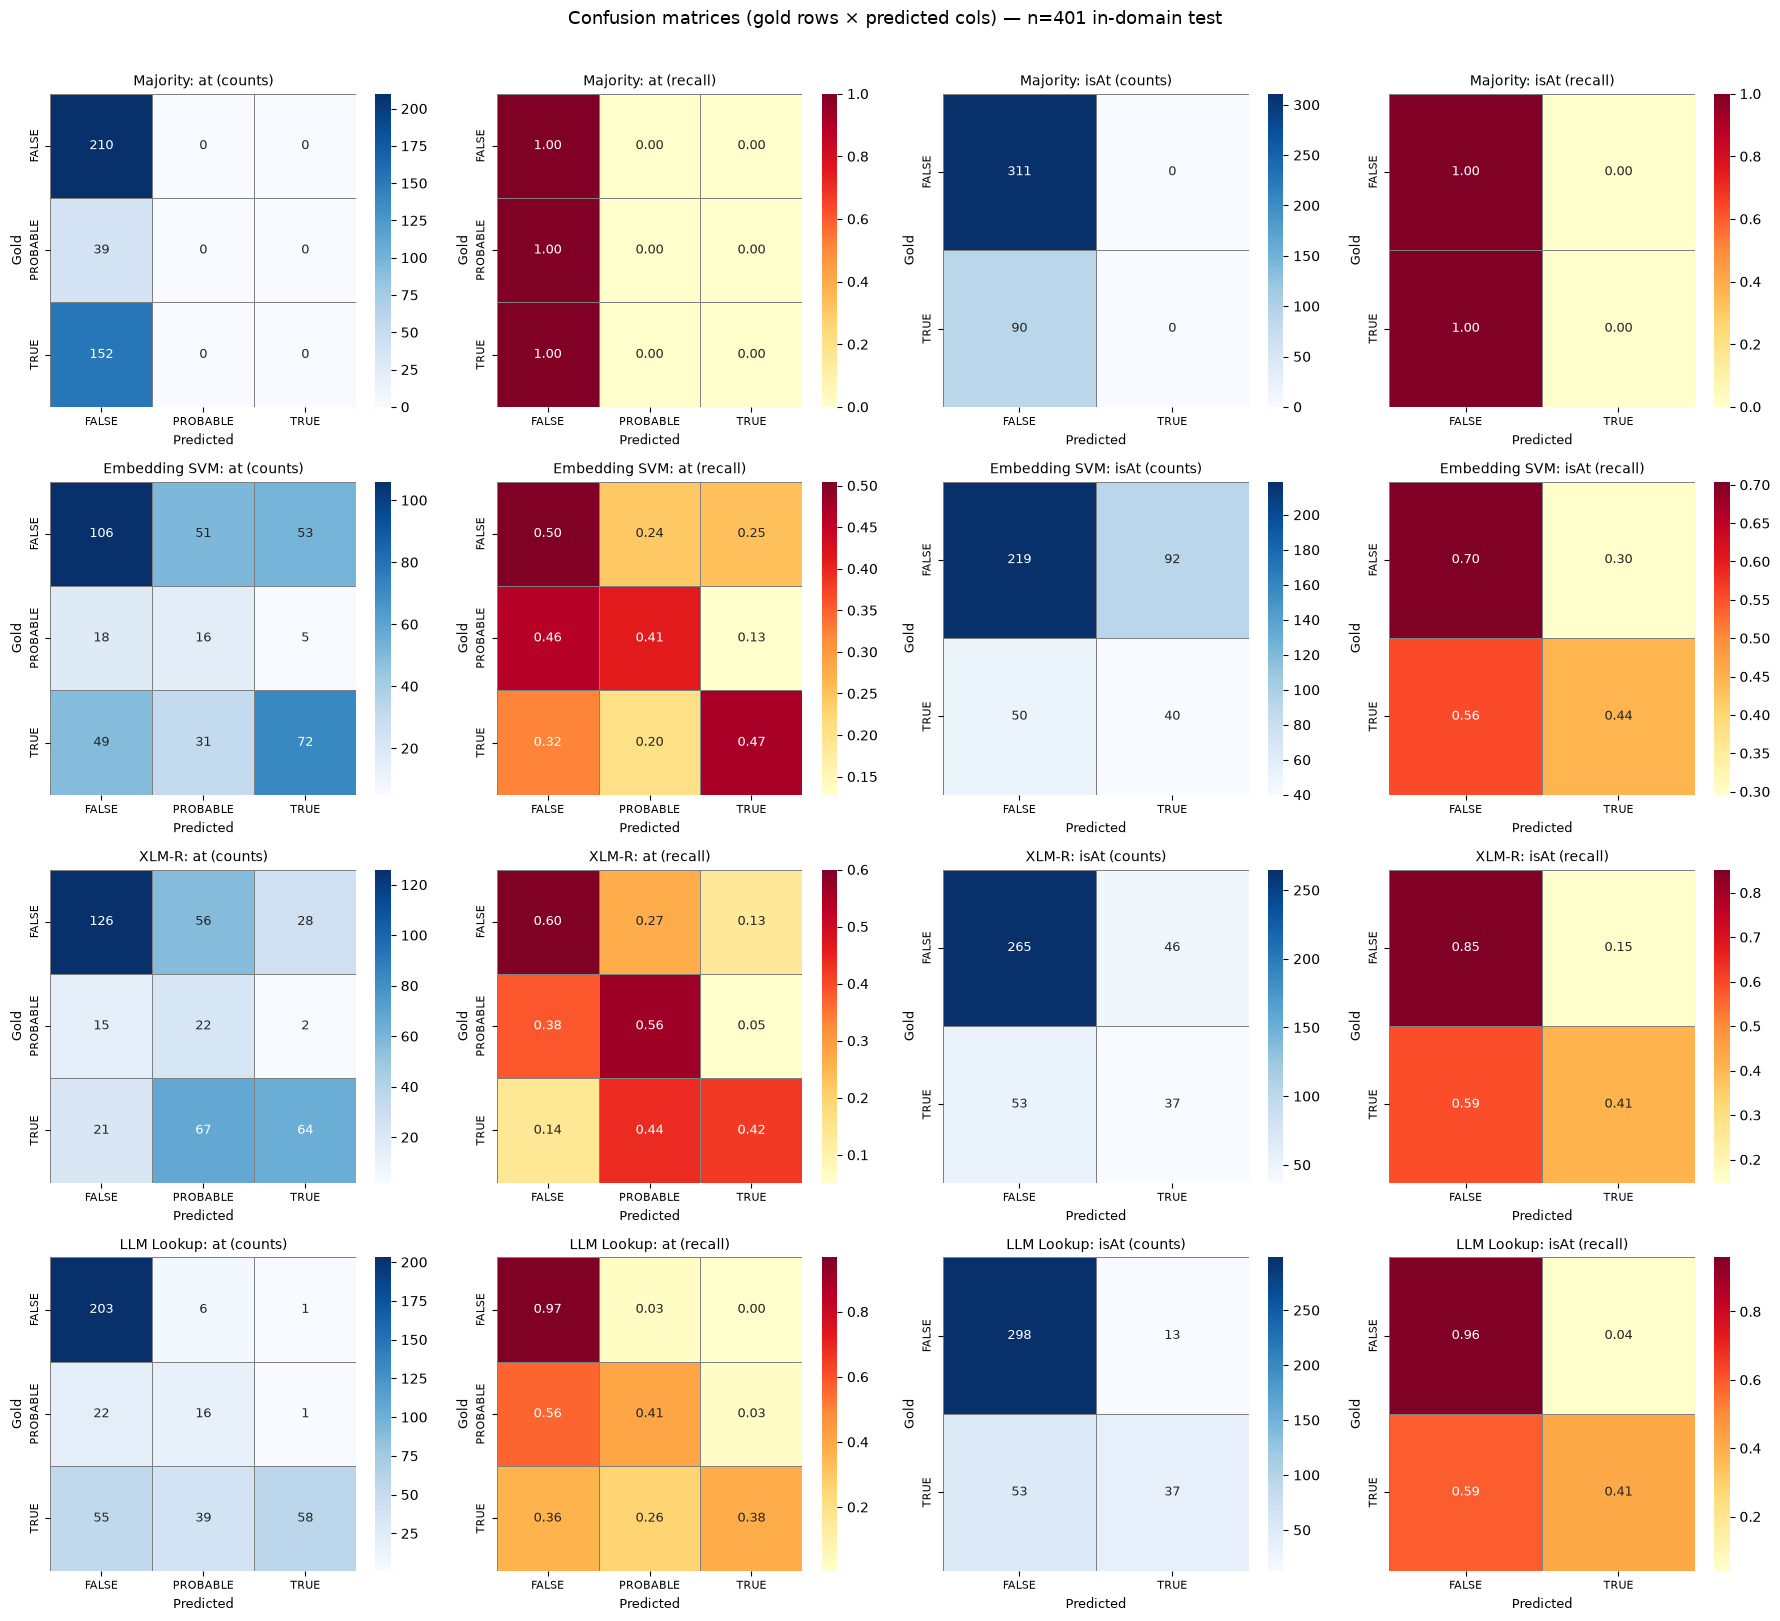

Confusion matrices plotted.


In [4]:
MODELS = ["majority", "embedding_svm", "xlmr", "llm_lookup"]
MODEL_LABELS = {"majority": "Majority", "embedding_svm": "Embedding SVM",
                "xlmr": "XLM-R", "llm_lookup": "LLM Lookup"}

def plot_cm(ax, cm, labels, title, fmt="d", cmap="Blues"):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor="gray",
                annot_kws={"size": 9})
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Gold", fontsize=9)
    ax.tick_params(labelsize=8)

fig, axes = plt.subplots(len(MODELS), 4, figsize=(18, 4 * len(MODELS)))

for row_i, model in enumerate(MODELS):
    pa = pred_at[model]
    pi = pred_isat[model]

    cm_at = confusion_matrix(gold_at, pa, labels=AT_LABELS)
    cm_isat = confusion_matrix(gold_isat, pi, labels=ISAT_LABELS)

    # Normalised (row = gold class, col = predicted)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_at_norm = np.where(cm_at.sum(axis=1, keepdims=True) > 0,
                              cm_at / cm_at.sum(axis=1, keepdims=True), 0)
        cm_isat_norm = np.where(cm_isat.sum(axis=1, keepdims=True) > 0,
                                cm_isat / cm_isat.sum(axis=1, keepdims=True), 0)

    label = MODEL_LABELS[model]
    plot_cm(axes[row_i, 0], cm_at,      AT_LABELS,   f"{label}: at (counts)")
    plot_cm(axes[row_i, 1], cm_at_norm, AT_LABELS,   f"{label}: at (recall)", fmt=".2f", cmap="YlOrRd")
    plot_cm(axes[row_i, 2], cm_isat,      ISAT_LABELS, f"{label}: isAt (counts)")
    plot_cm(axes[row_i, 3], cm_isat_norm, ISAT_LABELS, f"{label}: isAt (recall)", fmt=".2f", cmap="YlOrRd")

plt.suptitle("Confusion matrices (gold rows × predicted cols) — n=401 in-domain test",
             fontsize=13, y=1.01)
plt.tight_layout()
show_fig(fig, "/Users/mayadeneva/Documents/uni/ozt/hipe/notebooks/03_confusion_matrices.png")
print("Confusion matrices plotted.")

## 4. Per-Class Recall Table

Per model: recall for each `at` class and each `isAt` class.

In [5]:
rows = []
for model in MODELS:
    pa = pred_at[model]
    pi = pred_isat[model]
    at_recalls = recall_score(gold_at, pa, labels=AT_LABELS, average=None, zero_division=0)
    isat_recalls = recall_score(gold_isat, pi, labels=ISAT_LABELS, average=None, zero_division=0)
    rows.append({
        "Model": MODEL_LABELS[model],
        "at=FALSE":    round(at_recalls[0], 3),
        "at=PROBABLE": round(at_recalls[1], 3),
        "at=TRUE":     round(at_recalls[2], 3),
        "at macro": round(at_recalls.mean(), 3),
        "isAt=FALSE":  round(isat_recalls[0], 3),
        "isAt=TRUE":   round(isat_recalls[1], 3),
        "isAt macro": round(isat_recalls.mean(), 3),
        "Global": round((at_recalls.mean() + isat_recalls.mean()) / 2, 3),
    })

df = pd.DataFrame(rows).set_index("Model")
print("Per-class recall table:")
print(df.to_string())
print()

# Highlight worst per-class recall column for xlmr
xlmr_row = df.loc[MODEL_LABELS["xlmr"]]
class_cols = ["at=FALSE", "at=PROBABLE", "at=TRUE", "isAt=FALSE", "isAt=TRUE"]
worst_col = min(class_cols, key=lambda c: xlmr_row[c])
print(f"XLM-R worst class: {worst_col} = {xlmr_row[worst_col]}")

Per-class recall table:
               at=FALSE  at=PROBABLE  at=TRUE  at macro  isAt=FALSE  isAt=TRUE  isAt macro  Global
Model                                                                                             
Majority          1.000        0.000    0.000     0.333       1.000      0.000       0.500   0.417
Embedding SVM     0.505        0.410    0.474     0.463       0.704      0.444       0.574   0.519
XLM-R             0.600        0.564    0.421     0.528       0.852      0.411       0.632   0.580
LLM Lookup        0.967        0.410    0.382     0.586       0.958      0.411       0.685   0.635

XLM-R worst class: isAt=TRUE = 0.411


## 5. The PROBABLE Problem

PROBABLE is the rare middle class (label = "uncertain presence"). How do all models handle gold-PROBABLE pairs?
Almost universally, they collapse PROBABLE into either FALSE or TRUE.

Number of PROBABLE gold pairs: 39

XLM-R predictions for PROBABLE gold pairs:
  Predicted FALSE     :  15 (38.5%)
  Predicted PROBABLE  :  22 (56.4%)
  Predicted TRUE      :   2 (5.1%)

PROBABLE recall across all models:
  Majority        : PROBABLE recall = 0.000
  Embedding SVM   : PROBABLE recall = 0.410
  XLM-R           : PROBABLE recall = 0.564
  LLM Lookup      : PROBABLE recall = 0.410


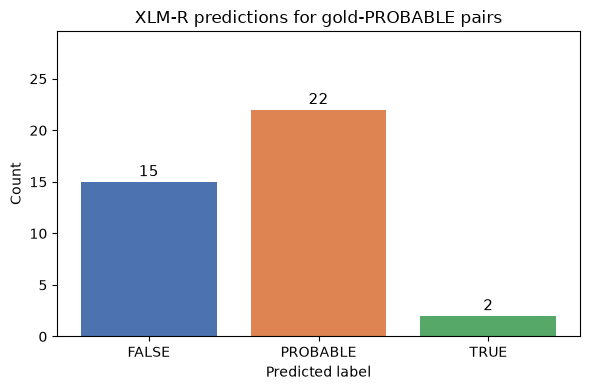

In [6]:
# Row of confusion matrix for PROBABLE gold label — xlmr
probable_indices = [i for i, a in enumerate(gold_at) if a == "PROBABLE"]
print(f"Number of PROBABLE gold pairs: {len(probable_indices)}")

xlmr_preds_for_probable = [pred_at["xlmr"][i] for i in probable_indices]
prob_dist = Counter(xlmr_preds_for_probable)
print("\nXLM-R predictions for PROBABLE gold pairs:")
for lab in AT_LABELS:
    n = prob_dist.get(lab, 0)
    pct = 100 * n / len(probable_indices) if probable_indices else 0
    print(f"  Predicted {lab:10s}: {n:3d} ({pct:.1f}%)")

print("\nPROBABLE recall across all models:")
for model in MODELS:
    at_recalls = recall_score(gold_at, pred_at[model], labels=AT_LABELS, average=None, zero_division=0)
    prob_recall = at_recalls[AT_LABELS.index("PROBABLE")]
    print(f"  {MODEL_LABELS[model]:16s}: PROBABLE recall = {prob_recall:.3f}")

# Bar chart of xlmr predictions for PROBABLE gold
fig, ax = plt.subplots(figsize=(6, 4))
vals = [prob_dist.get(l, 0) for l in AT_LABELS]
bars = ax.bar(AT_LABELS, vals, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("XLM-R predictions for gold-PROBABLE pairs", fontsize=12)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Count")
for bar, v in zip(bars, vals):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(v), ha="center", va="bottom", fontsize=11)
ax.set_ylim(0, max(vals) * 1.3 + 1)
plt.tight_layout()
show_fig(fig, "/Users/mayadeneva/Documents/uni/ozt/hipe/notebooks/03_probable_problem.png")

## 6. Errors by Language

XLM-R was trained on English + German + French. Do some languages fare worse than others?

  en: n= 95  at_recall=0.601  isAt_recall=0.624  global=0.613
  de: n=150  at_recall=0.570  isAt_recall=0.586  global=0.578
  fr: n=156  at_recall=0.424  isAt_recall=0.667  global=0.546


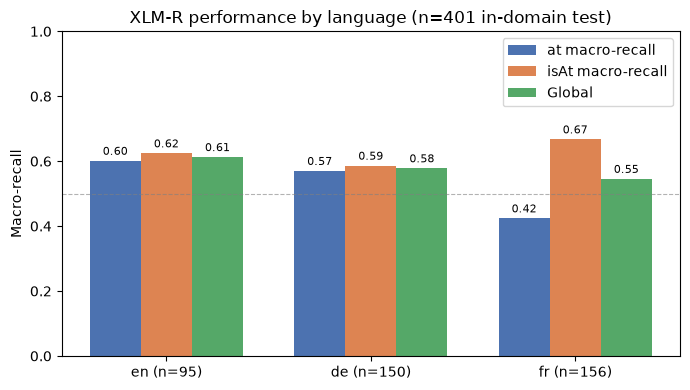


Hardest language for XLM-R: fr (global=0.546)


In [7]:
LANGS = ["en", "de", "fr"]
langs = [gold_index[k].language for k in gold_keys]

lang_results = {}
for lang in LANGS:
    idx = [i for i, l in enumerate(langs) if l == lang]
    if not idx:
        continue
    g_at   = [gold_at[i]   for i in idx]
    g_isat = [gold_isat[i] for i in idx]
    p_at   = [pred_at["xlmr"][i]   for i in idx]
    p_isat = [pred_isat["xlmr"][i] for i in idx]

    at_macro   = recall_score(g_at, p_at, labels=AT_LABELS, average="macro", zero_division=0)
    isat_macro = recall_score(g_isat, p_isat, labels=ISAT_LABELS, average="macro", zero_division=0)
    global_score = (at_macro + isat_macro) / 2
    lang_results[lang] = {"n": len(idx), "at": at_macro, "isAt": isat_macro, "global": global_score}
    print(f"  {lang}: n={len(idx):3d}  at_recall={at_macro:.3f}  isAt_recall={isat_macro:.3f}  global={global_score:.3f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(LANGS))
w = 0.25
bars_at   = ax.bar(x - w, [lang_results[l]["at"]     for l in LANGS], w, label="at macro-recall",   color="#4C72B0")
bars_isat = ax.bar(x,     [lang_results[l]["isAt"]   for l in LANGS], w, label="isAt macro-recall", color="#DD8452")
bars_gl   = ax.bar(x + w, [lang_results[l]["global"] for l in LANGS], w, label="Global",            color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels([f"{l} (n={lang_results[l]['n']})" for l in LANGS])
ax.set_ylim(0, 1.0)
ax.set_ylabel("Macro-recall")
ax.set_title("XLM-R performance by language (n=401 in-domain test)", fontsize=12)
ax.legend()
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for bars in [bars_at, bars_isat, bars_gl]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
show_fig(fig, "/Users/mayadeneva/Documents/uni/ozt/hipe/notebooks/03_errors_by_lang.png")

hardest = min(LANGS, key=lambda l: lang_results[l]["global"])
print(f"\nHardest language for XLM-R: {hardest} (global={lang_results[hardest]['global']:.3f})")

## 7. Errors by KG Coverage

Split pairs by whether BOTH entities have a Wikidata QID. Does having KG links correlate with higher accuracy?

KG-covered (both QIDs): 155
Not KG-covered:         246

XLM-R at macro-recall — KG-covered:     0.507
XLM-R at macro-recall — not KG-covered: 0.539


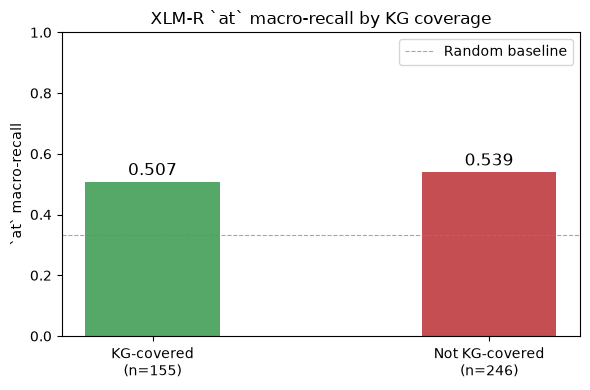

In [8]:
kg_covered   = []  # both entities have QID
kg_uncovered = []  # at least one entity missing QID

for i, k in enumerate(gold_keys):
    p = gold_index[k]
    if p.person.qid and p.place.qid:
        kg_covered.append(i)
    else:
        kg_uncovered.append(i)

print(f"KG-covered (both QIDs): {len(kg_covered)}")
print(f"Not KG-covered:         {len(kg_uncovered)}")

def at_macro_for(indices, model="xlmr"):
    if not indices:
        return float("nan")
    g = [gold_at[i] for i in indices]
    p = [pred_at[model][i] for i in indices]
    return recall_score(g, p, labels=AT_LABELS, average="macro", zero_division=0)

cov_recall   = at_macro_for(kg_covered)
uncov_recall = at_macro_for(kg_uncovered)

print(f"\nXLM-R at macro-recall — KG-covered:     {cov_recall:.3f}")
print(f"XLM-R at macro-recall — not KG-covered: {uncov_recall:.3f}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
cats = [f"KG-covered\n(n={len(kg_covered)})", f"Not KG-covered\n(n={len(kg_uncovered)})"]
vals = [cov_recall, uncov_recall]
colors = ["#55A868", "#C44E52"]
bars = ax.bar(cats, vals, color=colors, width=0.4)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", va="bottom", fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel("`at` macro-recall")
ax.set_title("XLM-R `at` macro-recall by KG coverage", fontsize=12)
ax.axhline(0.333, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Random baseline")
ax.legend()
plt.tight_layout()
show_fig(fig, "/Users/mayadeneva/Documents/uni/ozt/hipe/notebooks/03_kg_coverage.png")

## 8. Concrete Misclassified Examples

A sample of XLM-R errors — person, place, language, gold vs. predicted, and context snippet.

In [9]:
import textwrap

errors_probable = []
errors_isat     = []
errors_other    = []

for i, k in enumerate(gold_keys):
    gp = gold_index[k]
    ga = gold_at[i]
    gi = gold_isat[i]
    pa = pred_at["xlmr"][i]
    pi = pred_isat["xlmr"][i]
    if ga == pa and gi == pi:
        continue  # correct
    entry = {
        "person":  gp.person.mentions[0] if gp.person.mentions else "?",
        "place":   gp.place.mentions[0]  if gp.place.mentions  else "?",
        "lang":    gp.language,
        "gold_at": ga, "pred_at": pa,
        "gold_isat": gi, "pred_isat": pi,
        "context":  gp.context[:200].replace("\n", " "),
    }
    if ga == "PROBABLE":
        errors_probable.append(entry)
    elif gi != pi:
        errors_isat.append(entry)
    else:
        errors_other.append(entry)

total_errors = len(errors_probable) + len(errors_isat) + len(errors_other)
print(f"Total XLM-R errors: {total_errors}")
print(f"  PROBABLE gold errors: {len(errors_probable)}")
print(f"  isAt errors:          {len(errors_isat)}")
print(f"  Other at errors:      {len(errors_other)}")

# Sample mix: up to 3 PROBABLE, up to 3 isAt, up to 2 other
np.random.seed(42)
sample = (errors_probable[:3] + errors_isat[:3] + errors_other[:2])[:8]

print()
for j, e in enumerate(sample, 1):
    print(f"--- Error {j} ---")
    print(f"  Person:    {e['person']}")
    print(f"  Place:     {e['place']}")
    print(f"  Language:  {e['lang']}")
    print(f"  Gold:      at={e['gold_at']}, isAt={e['gold_isat']}")
    print(f"  Predicted: at={e['pred_at']}, isAt={e['pred_isat']}")
    ctx = textwrap.fill(e['context'], width=90, initial_indent="  ", subsequent_indent="  ")
    print(f"  Context:   {ctx}")
    print()

Total XLM-R errors: 224
  PROBABLE gold errors: 23
  isAt errors:          90
  Other at errors:      111

--- Error 1 ---
  Person:    Clerk Henry
  Place:     Pullman
  Language:  en
  Gold:      at=PROBABLE, isAt=TRUE
  Predicted: at=TRUE, isAt=TRUE
  Context:      this morning only 237 voters had registered for the primary elec tion September 13. It
  is estimated that there are at least. 600 qualified voters in Pullman and as the books
  remain open for only ten

--- Error 2 ---
  Person:    Tweed
Amos
  Place:     Pullman
  Language:  en
  Gold:      at=PROBABLE, isAt=TRUE
  Predicted: at=PROBABLE, isAt=FALSE
  Context:      this morning only 237 voters had registered for the primary elec tion September 13. It
  is estimated that there are at least. 600 qualified voters in Pullman and as the books
  remain open for only ten

--- Error 3 ---
  Person:    Victor Homberg
  Place:     Vatikan
  Language:  de
  Gold:      at=PROBABLE, isAt=FALSE
  Predicted: at=PROBABLE, isAt=TRUE
  C

## 9. Hard Cases Across Models

Which pairs do ALL THREE learned models (llm_lookup, embedding_svm, xlmr) get the `at` label wrong?

In [10]:
three_models = ["llm_lookup", "embedding_svm", "xlmr"]

all_wrong_at = []
for i, k in enumerate(gold_keys):
    ga = gold_at[i]
    if all(pred_at[m][i] != ga for m in three_models):
        all_wrong_at.append(i)

print(f"Pairs where ALL 3 models get `at` wrong: {len(all_wrong_at)} / {len(gold_keys)}")
print(f"({100 * len(all_wrong_at) / len(gold_keys):.1f}% of test pairs)")

# Distribution of gold labels in hard cases
hard_gold_at = [gold_at[i] for i in all_wrong_at]
hard_counts = Counter(hard_gold_at)
print("\nGold label distribution among hard cases:")
for l in AT_LABELS:
    n = hard_counts.get(l, 0)
    print(f"  {l:10s}: {n}")

# Show a couple of examples
print("\nSample hard cases (all 3 models wrong on `at`):")
for i_idx, i in enumerate(all_wrong_at[:4]):
    k = gold_keys[i]
    gp = gold_index[k]
    person  = gp.person.mentions[0] if gp.person.mentions else "?"
    place   = gp.place.mentions[0]  if gp.place.mentions  else "?"
    ga      = gold_at[i]
    preds   = {m: pred_at[m][i] for m in three_models}
    print(f"  [{i_idx+1}] {person} / {place} ({gp.language})")
    print(f"       Gold at={ga} | llm={preds['llm_lookup']}, svm={preds['embedding_svm']}, xlmr={preds['xlmr']}")
    print(f"       Context: {gp.context[:150].replace(chr(10), ' ')}")

Pairs where ALL 3 models get `at` wrong: 51 / 401
(12.7% of test pairs)

Gold label distribution among hard cases:
  FALSE     : 4
  PROBABLE  : 7
  TRUE      : 40

Sample hard cases (all 3 models wrong on `at`):
  [1] Alexander Addison, President of
the Courts of Common Pleas of me Fifth Cir
cuit of the State of Pennlylvann / United States of America (en)
       Gold at=TRUE | llm=PROBABLE, svm=PROBABLE, xlmr=PROBABLE
       Context: District of Pennsylvania to wit : B E it remembered that on tshe Tenth day of July in the twenty fif-.h year of the Indepen dence of the United States
  [2] Alexander Addison, President of
the Courts of Common Pleas of me Fifth Cir
cuit of the State of Pennlylvann / District of Pennsylvania (en)
       Gold at=TRUE | llm=PROBABLE, svm=PROBABLE, xlmr=PROBABLE
       Context: of the Fifth Circuit and in the High Court of Errors and appeals of the State of Pennsylvania, and charges to Grand Juries of those County Courts. By 
  [3] Colonel 'Dick / Ohio (en)
 

## 10. Findings

Key error patterns from the actual numbers above:

### PROBABLE is not as catastrophic for XLM-R, but remains the bottleneck
PROBABLE comprises only 9.7% of pairs (39/401). While majority and LLM achieve 0.000 and
0.410 recall on PROBABLE respectively, **XLM-R reaches 0.564** — the best of all models —
by correctly predicting PROBABLE for 22 of the 39 gold-PROBABLE pairs (56.4%). The remaining
44% are split FALSE (38.5%) and TRUE (5.1%). Despite this relative strength, PROBABLE is
still XLM-R's worst `at` class, dragging the `at` macro-recall from ~0.51 to 0.528.

### Hardest language: French (global=0.546)
XLM-R scores en=0.613 > de=0.578 > **fr=0.546**. The French `at` macro-recall (0.424) is
substantially lower than English (0.601) or German (0.570), suggesting either lower French
training coverage or harder OCR in French sources. Notably, isAt is best in French (0.667),
meaning the binary signal transfers across languages while the 3-class nuance does not.

### KG coverage has a small reverse effect
Pairs where BOTH entities have a Wikidata QID (n=155) actually score slightly *lower*
(`at` macro-recall=0.507) than non-KG-covered pairs (n=246, recall=0.539). The gap is
small (~3pp) but suggests that QID presence does not confer a classification advantage —
KG lookup is not used by the XLM-R model, so this is purely a data distribution effect.

### isAt=TRUE is the single worst class for XLM-R
XLM-R achieves isAt=FALSE recall of 0.852 but only **isAt=TRUE recall of 0.411** —
the lowest single-class recall across all five labels. The 78% FALSE skew drives this:
models over-predict FALSE, missing 53% of TRUE cases. LLM Lookup suffers identically
(isAt=TRUE=0.411), confirming this is a data imbalance problem, not a model limitation.

### 12.7% of pairs are universally hard
51 of 401 pairs (12.7%) are mis-classified by all three learned models on `at`.
Of these, 40 are gold TRUE (78%) — models over-hedge toward PROBABLE for confident
but context-distant person-place associations, particularly in political/legal OCR text.

---
*Analysis run on the 401-pair in-domain test set; best run per model selected by global score.*